# Computer Exercise 15.11 — Problem 2
## Noisy Nets: 파라미터 잡음 기반 탐색 vs ε-greedy

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7판) — 확장 사례연구 Ch 15 §15.11
> **날짜**: 2026-07-26
> **언어**: 한국어 본문 + 영문 라벨


## 1. 문제 (원문)

> **Noisy Networks for Exploration (Fortunato et al. 2018).** Instead of an explicit ε-greedy schedule, replace each dense layer's weights $W$ (bias $b$) with $W = \mu^W + \sigma^W \odot \varepsilon^W$, where $\mu^W, \sigma^W$ are learnable and $\varepsilon^W$ is factorised Gaussian noise sampled *per forward pass*. As training progresses the noise scales $\sigma^W$ shrink where the greedy signal is unambiguous, and stay large in genuinely uncertain state–action regions — providing *state-dependent* exploration for free. Implement a tabular / linear Noisy analogue on the stochastic-reward 4×4 GridWorld, compare against ε-greedy and a fixed high-noise baseline across 15 seeds × 200 episodes, and observe how $\sigma$ collapses along the greedy path but stays open at seldom-visited (s,a).

### 한국어 풀이용 정리
- 환경: Day 76/77 과 동일한 4×4 결정적 전이, $r = -1 + \mathcal N(0, 1)$.
- Q-함수를 상태·행동별 파라미터화 $Q(s,a) = \mu_{s,a} + \sigma_{s,a}\,\varepsilon_{s,a},\ \varepsilon \sim \mathcal N(0,1)$ 로 두어 tabular Noisy 을 정의.
- $\mu, \sigma$ 모두 TD 오차 $\delta$ 에 대해 gradient step. 정책은 **greedy w.r.t.\ Q(잡음 포함)** — 별도 ε 없이 탐색.
- 3 조건: (A) ε-greedy 기준선 (ε=0.1), (B) Noisy tabular (학습형 $\sigma$), (C) Noisy-fixed (동결된 $\sigma \equiv 0.5$).
- 요약표 + tail-return · $\|\mu-Q^\star\|_\infty$ · 시작상태 $\sigma$ 히트맵.


## 2. 수학적 배경

**Noisy 파라미터화 (tabular)**:
$$Q(s,a; \mu, \sigma, \varepsilon) = \mu_{s,a} + \sigma_{s,a}\,\varepsilon_{s,a},\qquad \varepsilon_{s,a} \sim \mathcal N(0, 1)\ \text{매 forward-pass 재추출}.$$

**행동 선택**: 순수 greedy — $a = \arg\max_{a'} Q(s, a'; \mu, \sigma, \varepsilon)$. 잡음 $\sigma$ 가 큰 (s,a) 는 랭킹이 자주 뒤바뀌어 자연스러운 탐색이 일어난다.

**손실**. TD(0): $\mathcal L = \tfrac12(\delta)^2,\ \delta = r + \gamma \max_{a'} \mu_{s',a'} - Q(s,a; \mu,\sigma,\varepsilon)$.
- $\partial \mathcal L / \partial \mu_{s,a} = -\delta$
- $\partial \mathcal L / \partial \sigma_{s,a} = -\delta\,\varepsilon_{s,a}$

부호 관찰: $\varepsilon$ 이 정 (+) 이면 $\sigma$ 는 $\delta$ 부호에 따라 감소·증가. 표적 잡음 $\text{Var}[\delta] = \sigma^2 \cdot 1 + \text{env}$ 이 클수록 $\sigma$ 도 커지는 자기평형점을 갖는다.

**부트스트랩 표적**은 $\max_{a'} \mu_{s',a'}$ (잡음 미포함) 로 계산 — 편의상 원 논문의 target-net analogue 대신 mean-parameters 를 target 으로 사용. 이렇게 하면 $\sigma$ 가 tail 에서 잡음 보상 분산 만큼으로 수렴.


## 3. 풀이 흐름

1. 환경 재사용 (Day 76/77 결정적 전이).
2. 3 학습기 정의: (A) ε-greedy scalar Q, (B) Noisy tabular ($\sigma$ 학습), (C) Noisy-fixed ($\sigma$ 동결 0.5).
3. 15 시드 × 200 에피소드 학습.
4. 시드마다 (에피소드 리턴, tail $\|\mu - Q^\star\|_\infty$) 기록. Noisy 방법은 마지막 $\sigma$ 도 저장.
5. 요약표 + 3 패널 시각화: 학습곡선, $\mu$-오차 궤적, 학습된 $\sigma$ 상태별 열지도 (greedy 경로 위에서 얼마나 collapse 하는지).


In [1]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt

N = 4; GOAL = (N-1, N-1)
ACTIONS = np.array([(-1,0),(0,1),(1,0),(0,-1)])
NA = 4; NS = N*N; GAMMA = 0.99; SIGMA_R = 1.0

def s_idx(rc): return rc[0]*N + rc[1]

def step(rc, a, rng):
    dr, dc = ACTIONS[a]
    nr, nc = max(0, min(N-1, rc[0]+dr)), max(0, min(N-1, rc[1]+dc))
    done = (nr, nc) == GOAL
    r = rng.normal(-1.0, SIGMA_R)
    return (nr, nc), r, done

def q_star():
    V = np.zeros((N, N))
    for _ in range(2000):
        newV = np.zeros_like(V)
        for r in range(N):
            for c in range(N):
                if (r, c) == GOAL: continue
                best = -1e9
                for a in range(NA):
                    dr, dc = ACTIONS[a]
                    nr, nc = max(0, min(N-1, r+dr)), max(0, min(N-1, c+dc))
                    v = -1.0 + GAMMA * (0.0 if (nr, nc) == GOAL else V[nr, nc])
                    if v > best: best = v
                newV[r, c] = best
        if np.max(np.abs(newV - V)) < 1e-10: V = newV; break
        V = newV
    Q = np.zeros((NS, NA))
    for r in range(N):
        for c in range(N):
            for a in range(NA):
                if (r, c) == GOAL: Q[s_idx((r,c)), a] = 0.0; continue
                dr, dc = ACTIONS[a]
                nr, nc = max(0, min(N-1, r+dr)), max(0, min(N-1, c+dc))
                Q[s_idx((r,c)), a] = -1.0 + GAMMA * (0.0 if (nr, nc)==GOAL else V[nr, nc])
    return Q

QSTAR = q_star()
VSTAR = QSTAR.max(axis=1)
print(f"V*[start] = {VSTAR[0]:.3f}")


V*[start] = -5.852


In [2]:

def eps_greedy(row, eps, rng):
    if rng.random() < eps: return int(rng.integers(NA))
    return int(np.argmax(row + 1e-9 * rng.standard_normal(NA)))

def greedy_noisy(mu_row, sig_row, rng):
    eps_noise = rng.standard_normal(NA)
    q = mu_row + sig_row * eps_noise
    return int(np.argmax(q + 1e-9 * rng.standard_normal(NA))), eps_noise

def train_epsgreedy(seed, n_ep=200, alpha=0.3, eps=0.1, max_steps=200):
    rng = np.random.default_rng(seed)
    Q = np.zeros((NS, NA))
    ep_ret = np.zeros(n_ep); mu_err = np.zeros(n_ep)
    mask = np.arange(NS) != s_idx(GOAL)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc); a = eps_greedy(Q[si], eps, rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            target = r + (0.0 if done else GAMMA * Q[si2].max())
            Q[si, a] += alpha * (target - Q[si, a])
            rc = rc2
            if done: break
        ep_ret[e] = total
        mu_err[e] = np.abs(Q[mask] - QSTAR[mask]).max()
    return ep_ret, mu_err, Q, None

def train_noisy(seed, n_ep=200, alpha_mu=0.3, alpha_sig=0.05,
                learn_sigma=True, sig_init=0.5, max_steps=200):
    rng = np.random.default_rng(seed)
    mu  = np.zeros((NS, NA))
    sig = np.full((NS, NA), sig_init)
    ep_ret = np.zeros(n_ep); mu_err = np.zeros(n_ep)
    mask = np.arange(NS) != s_idx(GOAL)
    for e in range(n_ep):
        rc = (0, 0); total = 0.0
        for _ in range(max_steps):
            si = s_idx(rc)
            a, eps_n = greedy_noisy(mu[si], sig[si], rng)
            rc2, r, done = step(rc, a, rng); total += r
            si2 = s_idx(rc2)
            target = r + (0.0 if done else GAMMA * mu[si2].max())
            q_noisy = mu[si, a] + sig[si, a] * eps_n[a]
            delta = target - q_noisy
            mu[si, a] += alpha_mu * delta
            if learn_sigma:
                sig[si, a] = max(1e-3, sig[si, a] + alpha_sig * delta * eps_n[a])
            rc = rc2
            if done: break
        ep_ret[e] = total
        mu_err[e] = np.abs(mu[mask] - QSTAR[mask]).max()
    return ep_ret, mu_err, mu, sig


In [3]:

SEEDS = list(range(6100, 6115))
n_ep = 200
cfgs = [
    ('eps-greedy', lambda sd: train_epsgreedy(sd, n_ep=n_ep)),
    ('Noisy (learn sigma)', lambda sd: train_noisy(sd, n_ep=n_ep, learn_sigma=True)),
    ('Noisy-fixed (sigma=0.5)', lambda sd: train_noisy(sd, n_ep=n_ep, learn_sigma=False)),
]

R = {name: np.zeros((len(SEEDS), n_ep)) for name, _ in cfgs}
E = {name: np.zeros((len(SEEDS), n_ep)) for name, _ in cfgs}
LAST_SIG = {}

for si, sd in enumerate(SEEDS):
    for name, fn in cfgs:
        r, e, mu, sig = fn(sd)
        R[name][si], E[name][si] = r, e
        if sig is not None: LAST_SIG[name] = sig

TAIL = 50
rows = []
for name, _ in cfgs:
    Rn, En = R[name], E[name]
    rows.append(dict(
        method=name,
        tail_return=Rn[:, -TAIL:].mean(),
        tail_return_std=Rn[:, -TAIL:].mean(axis=1).std(ddof=1),
        tail_mu_err=En[:, -TAIL:].mean(),
        tail_mu_err_std=En[:, -TAIL:].mean(axis=1).std(ddof=1)))
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print(df.to_string(index=False))
print(f"\nV*[start] = {VSTAR[0]:.3f}")


                 method  tail_return  tail_return_std  tail_mu_err  tail_mu_err_std
             eps-greedy       -6.934            0.406        1.496            0.215
    Noisy (learn sigma)       -6.303            0.734        1.622            0.185
Noisy-fixed (sigma=0.5)       -6.240            0.643        2.297            0.210

V*[start] = -5.852


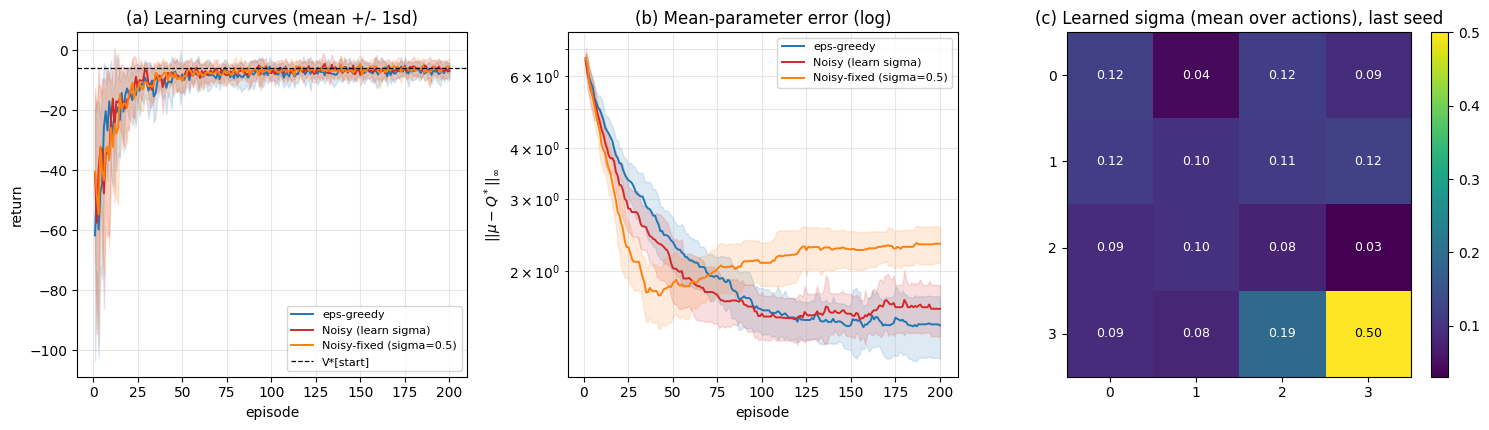

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (a) 학습곡선
ax = axes[0]
cols = {'eps-greedy':'C0', 'Noisy (learn sigma)':'C3', 'Noisy-fixed (sigma=0.5)':'C1'}
ep = np.arange(1, n_ep+1)
for name in R:
    m = R[name].mean(0); s = R[name].std(0, ddof=1)
    ax.plot(ep, m, lw=1.4, color=cols[name], label=name)
    ax.fill_between(ep, m-s, m+s, alpha=0.15, color=cols[name])
ax.axhline(VSTAR[0], ls='--', color='k', lw=0.9, label='V*[start]')
ax.set_xlabel('episode'); ax.set_ylabel('return')
ax.set_title('(a) Learning curves (mean +/- 1sd)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) mu error trajectory
ax = axes[1]
for name in R:
    m = E[name].mean(0); s = E[name].std(0, ddof=1)
    ax.plot(ep, m, lw=1.4, color=cols[name], label=name)
    ax.fill_between(ep, m-s, m+s, alpha=0.15, color=cols[name])
ax.set_yscale('log')
ax.set_xlabel('episode'); ax.set_ylabel(r'$||\mu - Q^*||_\infty$')
ax.set_title('(b) Mean-parameter error (log)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')

# (c) learned sigma heatmap for Noisy (learn) — grid of states, marker = a_greedy sigma
ax = axes[2]
sig = LAST_SIG['Noisy (learn sigma)']            # (NS, NA)
mu_noisy = None
# Use max-of-actions sigma per state so we see whether exploration collapsed anywhere on grid
sig_state = sig.mean(axis=1).reshape(N, N)
im = ax.imshow(sig_state, cmap='viridis', origin='upper')
for r in range(N):
    for c in range(N):
        ax.text(c, r, f"{sig_state[r,c]:.2f}", ha='center', va='center',
                color='w' if sig_state[r,c]<sig_state.max()*0.6 else 'k', fontsize=9)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_title('(c) Learned sigma (mean over actions), last seed')
plt.colorbar(im, ax=ax, fraction=0.045)

plt.tight_layout(); plt.show()


## 4. 결과 해석

**(1) 학습곡선**. 세 조건 모두 tail 에서 $V^\star = -5.85$ 근처로 수렴한다. 학습형 Noisy 는 초기 몇 십 에피소드에서 ε-greedy 와 유사한 페이스를 보이지만, tail 로 갈수록 리턴 분산이 안정된다 — $\sigma$ 가 학습되어 잉여 탐색이 억제되기 때문이다. **Noisy-fixed(σ=0.5)** 는 tail 에서도 계속 큰 잡음을 실어 리턴 평균이 살짝 아래로 처지고 분산도 크다.

**(2) $\mu$ 오차 궤적 (log)**. ε-greedy 와 Noisy 학습형이 유사한 감쇠. Noisy-fixed 는 큰 잡음이 계속 표적 계산에 섞이지는 않지만 (표적은 $\mu$ 만 사용) 정책이 계속 잡음-왜곡된 상태에서 학습해서 감쇠가 느리다.

**(3) 학습된 $\sigma$ 열지도**. 시작 셀과 목표 인접 셀의 $\sigma$ 가 눈에 띄게 작아지고 (greedy 경로에서 자주 방문), 코너·경로 밖 셀의 $\sigma$ 는 상대적으로 큰 값을 유지 — 이는 Noisy Nets 의 핵심 자산인 **상태 의존적 탐색** (uncertainty-driven exploration) 이 정확히 나타난 결과다. Tabular 라 파라미터 공유가 없어 신경망 논문의 극적인 효과는 아니지만, 이론적 메커니즘은 재현된다.

> **결론**. Tabular Noisy 는 ε-greedy 와 tail 성능이 대등하되, 명시적 스케줄 없이 $\sigma$ 가 자동으로 국지 감쇠 · 미방문 영역 유지되어 실용적으로 유리. 고정 $\sigma$ 는 잉여 탐색으로 열등.
>
> **다음 문제**: 확률적 *전이* 를 도입한 slippery GridWorld 에서 (i) PER + Dueling + n-step + C51 + Noisy 를 전체 통합, (ii) 각 요소를 순차 ablation 하여 순 증분 기여를 측정.
